In [16]:
import sys
sys.path.insert(0, "..")


In [17]:
from src.models.features import build_dataset, time_series_split
from src.models.logistic_model import train_logistic

In [18]:
# ── Build dataset ─────────────────────────────────────────────────
X, y, dates = build_dataset("RELIANCE.NS", horizon=5, threshold=0.0)

# ── Split chronologically ─────────────────────────────────────────
X_train, X_test, y_train, y_test = time_series_split(X, y, test_size=0.2)

# ── Train and evaluate ────────────────────────────────────────────
model, scaler, metrics = train_logistic(X_train, y_train, X_test, y_test)

Dataset built for RELIANCE.NS
  Total samples : 445
  Features      : 13
  UP days       : 219 (49.2%)
  DOWN days     : 226 (50.8%)
  Date range    : 2024-09-12 → 2026-06-26
Train: 356 days (2024-09-12 → 2026-02-16)
Test:  89 days  (2026-02-17 → 2026-06-26)

═════════════════════════════════════════════
  LOGISTIC REGRESSION RESULTS
═════════════════════════════════════════════
  Accuracy : 0.5506  (55.1%)
  ROC-AUC  : 0.5976

  Classification Report:
              precision    recall  f1-score   support

        DOWN       0.60      0.52      0.56        48
          UP       0.51      0.59      0.55        41

    accuracy                           0.55        89
   macro avg       0.55      0.55      0.55        89
weighted avg       0.56      0.55      0.55        89

  Confusion Matrix:
               Predicted DOWN  Predicted UP
  Actual DOWN         25              23
  Actual UP           17              24

  Feature Coefficients (sorted by importance):
       Feature  Coeffi

In [19]:
# ── Visualise predictions over time ──────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

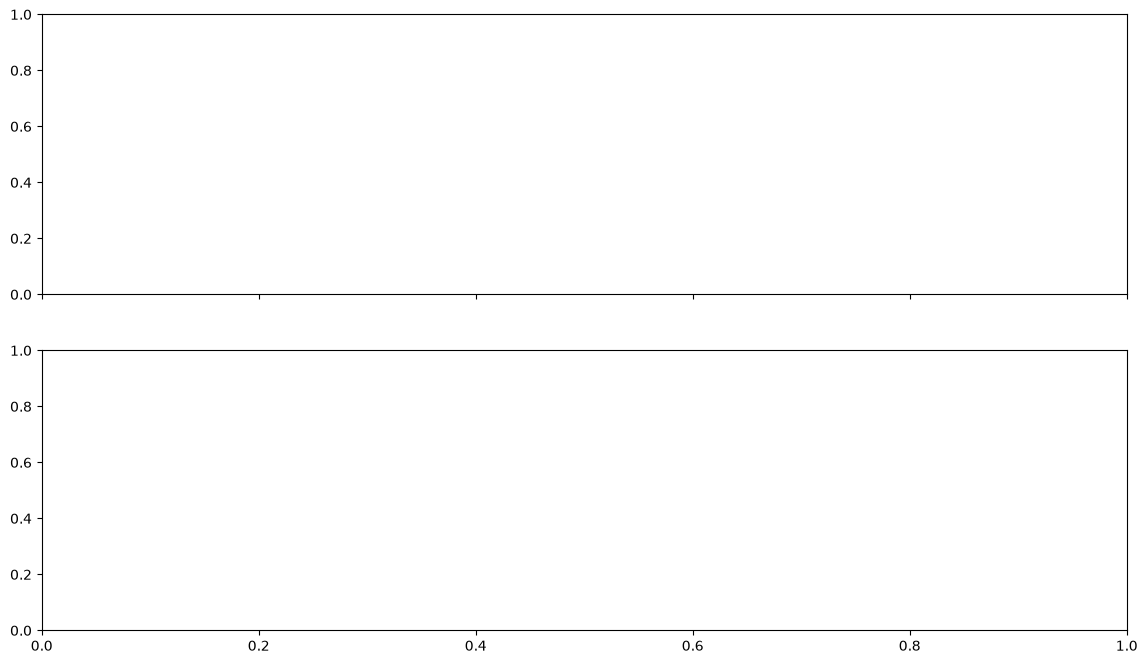

In [20]:

# Probability of UP over the test period
test_dates = X_test.index
prob_up = metrics["y_pred_proba"]
actual  = y_test.values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)



# Panel 1: Predicted probability vs actual outcome

In [21]:
ax1.plot(test_dates, prob_up, color="#1565C0", lw=1, label="P(UP)")
ax1.axhline(0.5, color="gray", lw=0.8, linestyle="--")
ax1.scatter(test_dates[actual == 1], prob_up[actual == 1],
            color="#43A047", s=15, alpha=0.6, label="Actually UP", zorder=3)
ax1.scatter(test_dates[actual == 0], prob_up[actual == 0],
            color="#E53935", s=15, alpha=0.6, label="Actually DOWN", zorder=3)
ax1.set_ylabel("P(UP) from model")
ax1.set_title("Logistic Regression — Predicted Probability vs Actual Outcome")
ax1.legend()
ax1.grid(alpha=0.2)

# Panel 2: Cumulative return if we traded on the signal
# Buy when model says P(UP) > 0.55, else stay in cash

In [22]:
threshold = 0.55
position  = (prob_up > threshold).astype(int)

# Load price data to compute actual returns

In [23]:
from src.data.database import load_prices
prices = load_prices("RELIANCE.NS")
test_returns = prices["Close"].pct_change().reindex(test_dates)

strategy_returns = position * test_returns
buy_hold_returns = test_returns

cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_buyhold  = (1 + buy_hold_returns).cumprod()

ax2.plot(test_dates, cumulative_strategy, color="#1565C0",
         lw=1.5, label=f"Model (threshold={threshold})")
ax2.plot(test_dates, cumulative_buyhold,  color="#FF6F00",
         lw=1.5, label="Buy and hold")
ax2.axhline(1.0, color="gray", lw=0.7)
ax2.set_ylabel("Cumulative Return")
ax2.set_title("Strategy vs Buy-and-Hold")
ax2.legend()
ax2.grid(alpha=0.2)

fig.tight_layout()
fig.savefig("../data/logistic_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:

import matplotlib.pyplot as plt
import numpy as np

# ── Feature importance bar chart ──────────────────────────────────

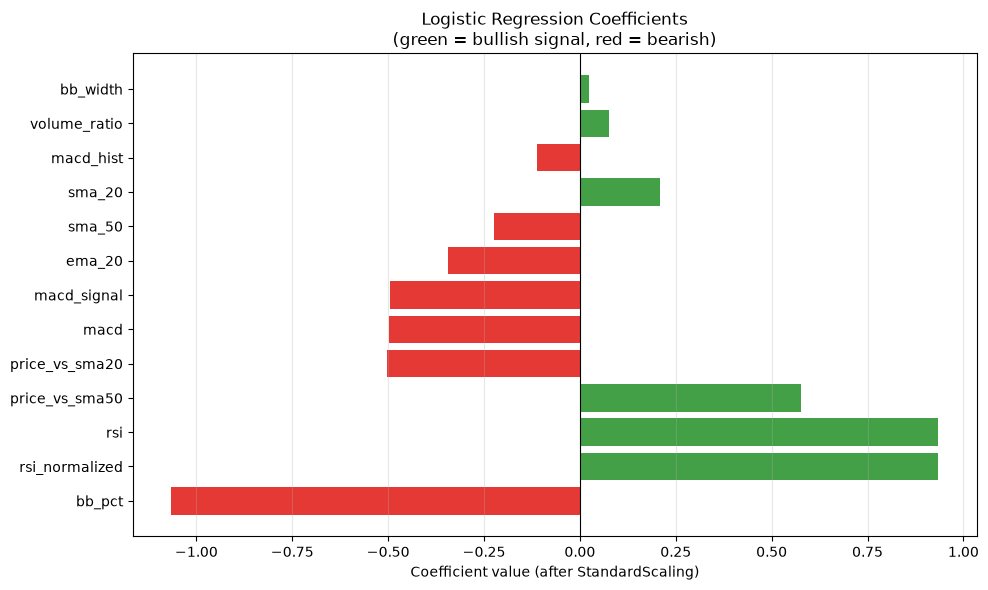

In [25]:
coefs    = model.coef_[0]
features = X_train.columns.tolist()
sorted_idx = np.argsort(np.abs(coefs))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [features[i] for i in sorted_idx],
    [coefs[i] for i in sorted_idx],
    color=["#43A047" if c > 0 else "#E53935" for c in [coefs[i] for i in sorted_idx]]
)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic Regression Coefficients\n(green = bullish signal, red = bearish)", fontsize=12)
ax.set_xlabel("Coefficient value (after StandardScaling)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../data/feature_importance.png", dpi=150)
plt.show()

In [26]:
print("\nModel interpretation:")
print("─" * 50)
for i in sorted_idx[:5]:
    direction = "bullish ↑" if coefs[i] > 0 else "bearish ↓"
    print(f"  {features[i]:20s}  coef={coefs[i]:+.3f}  ({direction})")


Model interpretation:
──────────────────────────────────────────────────
  bb_pct                coef=-1.066  (bearish ↓)
  rsi_normalized        coef=+0.935  (bullish ↑)
  rsi                   coef=+0.935  (bullish ↑)
  price_vs_sma50        coef=+0.575  (bullish ↑)
  price_vs_sma20        coef=-0.502  (bearish ↓)
